<a href="https://colab.research.google.com/github/drlukeweng/NCHU/blob/main/Week3_Lab1_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Medical Image Segmentation
## 智慧醫療中的醫學影像 | Week 3

**Learning Objectives:**
- Implement classical segmentation algorithms from scratch
- Apply thresholding, region growing, and active contours
- Build and train a Mini U-Net with synthetic medical data
- Evaluate segmentation quality with standard metrics

**Estimated Time:** 90 minutes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
from scipy.ndimage import label, binary_dilation, binary_erosion
from skimage import data, filters, measure, morphology
from skimage.segmentation import active_contour, watershed
from skimage.draw import disk, ellipse
from skimage.filters import threshold_otsu, threshold_local
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded successfully
NumPy version: 2.0.2


## Part 1: Creating a Synthetic CT-like Image

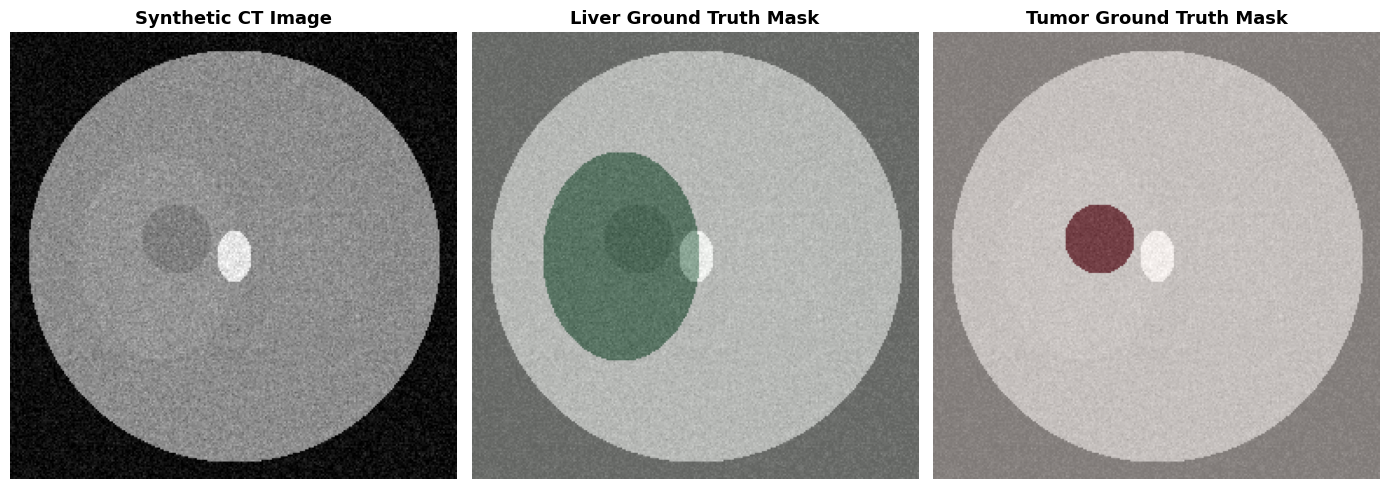

Image shape: (256, 256), dtype: float64
Intensity range: [0.000, 1.000]


In [ ]:
def create_synthetic_ct(size=256, noise_level=0.05, seed=42):
    """Create a synthetic CT-like image with organs"""
    np.random.seed(seed)
    image = np.zeros((size, size))

    # Background (air) ~ -1000 HU → normalized to 0.05
    image += 0.05

    # Body outline (soft tissue) ~ 50 HU → normalized to 0.55
    rr, cc = disk((size//2, size//2), size//2 - 10)
    image[rr, cc] = 0.55

    # Liver (right side) ~ 60 HU → 0.58
    rr, cc = ellipse(size//2, size//3, 60, 45)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    image[rr[valid], cc[valid]] = 0.58

    # Spleen (left side) ~ 55 HU → 0.56
    rr, cc = disk((size//2, 2*size//3), 30)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    image[rr[valid], cc[valid]] = 0.56

    # Tumor in liver ~ 40 HU → 0.50 (hypodense)
    rr, cc = disk((size//2 - 10, size//3 + 10), 20)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    image[rr[valid], cc[valid]] = 0.50

    # Spine (bone) ~ 400 HU → 0.90
    rr, cc = ellipse(size//2, size//2, 15, 10)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    image[rr[valid], cc[valid]] = 0.90

    # Add Gaussian noise
    noise = np.random.normal(0, noise_level, image.shape)
    image = np.clip(image + noise, 0, 1)

    return image

# Create ground truth mask for the liver
def create_liver_mask(size=256):
    mask = np.zeros((size, size), dtype=bool)
    rr, cc = ellipse(size//2, size//3, 60, 45)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    mask[rr[valid], cc[valid]] = True
    return mask

# Create tumor mask
def create_tumor_mask(size=256):
    mask = np.zeros((size, size), dtype=bool)
    rr, cc = disk((size//2 - 10, size//3 + 10), 20)
    valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
    mask[rr[valid], cc[valid]] = True
    return mask

image = create_synthetic_ct()
liver_gt = create_liver_mask()
tumor_gt = create_tumor_mask()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Synthetic CT Image', fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[1].imshow(liver_gt, alpha=0.4, cmap='Greens')
axes[1].set_title('Liver Ground Truth Mask', fontsize=13, fontweight='bold')
axes[1].axis('off')
axes[2].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(tumor_gt, alpha=0.5, cmap='Reds')
axes[2].set_title('Tumor Ground Truth Mask', fontsize=13, fontweight='bold')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('/tmp/ct_image.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Intensity range: [{image.min():.3f}, {image.max():.3f}]")

## Part 2: Evaluation Metrics

In [ ]:
def dice_coefficient(pred, gt):
    """Dice Similarity Coefficient = 2*|A∩B| / (|A|+|B|)"""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-8)

def iou_score(pred, gt):
    """Intersection over Union = |A∩B| / |A∪B|"""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-8)

def hausdorff_distance(pred, gt):
    """95th percentile Hausdorff distance (simplified)"""
    from scipy.spatial.distance import directed_hausdorff
    pred_pts = np.column_stack(np.where(pred))
    gt_pts = np.column_stack(np.where(gt))
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return float('inf')
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return max(d1, d2)

def evaluate_segmentation(pred, gt, method_name):
    dice = dice_coefficient(pred, gt)
    iou = iou_score(pred, gt)
    hd = hausdorff_distance(pred, gt)
    print(f"📊 {method_name}:")
    print(f"   Dice: {dice:.4f} | IoU: {iou:.4f} | Hausdorff: {hd:.1f} px")
    return {'method': method_name, 'dice': dice, 'iou': iou, 'hausdorff': hd}

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


## Part 3: Thresholding Methods

📊 Global Threshold (T=0.52):
   Dice: 0.3307 | IoU: 0.1981 | Hausdorff: 116.0 px
📊 Otsu Threshold (T=0.275):
   Dice: 0.3242 | IoU: 0.1935 | Hausdorff: 116.0 px


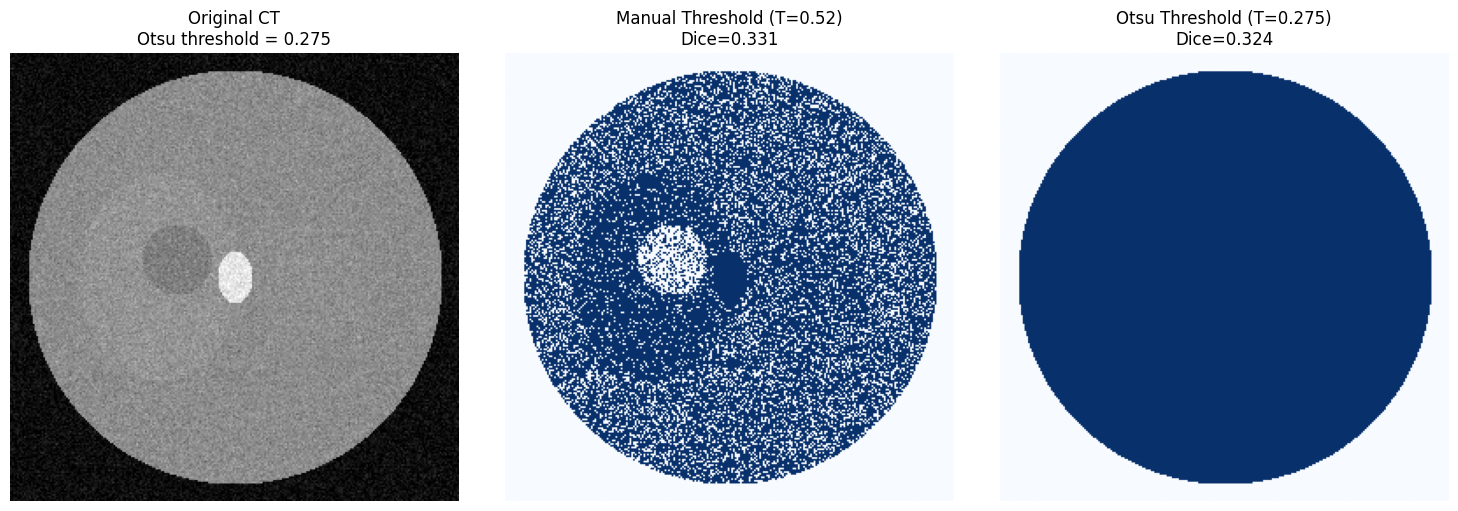


⚠️ Note: Thresholding segments ALL pixels above threshold,
not just the liver. Post-processing needed!


In [ ]:
# Global thresholding
def global_threshold(image, threshold):
    return image > threshold

# Otsu's thresholding
def otsu_threshold(image):
    threshold = threshold_otsu(image)
    return image > threshold, threshold

# Manual threshold
manual_thresh = 0.52
manual_seg = global_threshold(image, manual_thresh)

# Otsu's method
otsu_seg, otsu_T = otsu_threshold(image)

# Evaluate
results = []
results.append(evaluate_segmentation(manual_seg, liver_gt, "Global Threshold (T=0.52)"))
results.append(evaluate_segmentation(otsu_seg, liver_gt, f"Otsu Threshold (T={otsu_T:.3f})"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title(f'Original CT\nOtsu threshold = {otsu_T:.3f}')
axes[0].axis('off')
axes[1].imshow(manual_seg, cmap='Blues')
axes[1].set_title(f'Manual Threshold (T={manual_thresh})\nDice={dice_coefficient(manual_seg, liver_gt):.3f}')
axes[1].axis('off')
axes[2].imshow(otsu_seg, cmap='Blues')
axes[2].set_title(f'Otsu Threshold (T={otsu_T:.3f})\nDice={dice_coefficient(otsu_seg, liver_gt):.3f}')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("\n⚠️ Note: Thresholding segments ALL pixels above threshold,")
print("not just the liver. Post-processing needed!")

## Part 4: Region Growing

📊 Region Growing (liver seed):
   Dice: 0.1569 | IoU: 0.0852 | Hausdorff: 50.4 px


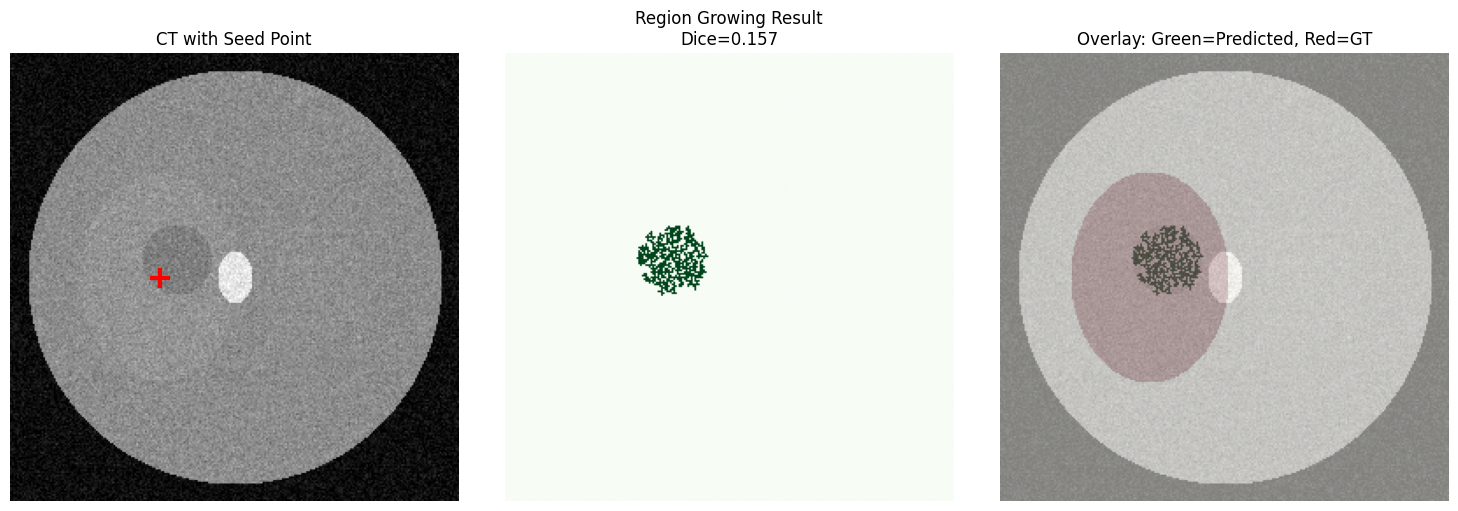

In [ ]:
def region_growing(image, seed, tolerance=0.05, max_iter=10000):
    """Simple region growing segmentation"""
    rows, cols = image.shape
    visited = np.zeros_like(image, dtype=bool)
    segmented = np.zeros_like(image, dtype=bool)

    seed_intensity = image[seed[0], seed[1]]
    queue = [seed]
    visited[seed[0], seed[1]] = True

    neighbors_4 = [(-1,0), (1,0), (0,-1), (0,1)]

    iter_count = 0
    while queue and iter_count < max_iter:
        y, x = queue.pop(0)
        segmented[y, x] = True
        iter_count += 1

        for dy, dx in neighbors_4:
            ny, nx = y + dy, x + dx
            if 0 <= ny < rows and 0 <= nx < cols and not visited[ny, nx]:
                if abs(image[ny, nx] - seed_intensity) < tolerance:
                    visited[ny, nx] = True
                    queue.append((ny, nx))

    return segmented

# Seed point inside the liver (center of liver region)
liver_seed = (128, 85)
liver_rg = region_growing(image, liver_seed, tolerance=0.08)

results.append(evaluate_segmentation(liver_rg, liver_gt, "Region Growing (liver seed)"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].plot(liver_seed[1], liver_seed[0], 'r+', markersize=15, markeredgewidth=3)
axes[0].set_title('CT with Seed Point')
axes[0].axis('off')
axes[1].imshow(liver_rg, cmap='Greens')
axes[1].set_title(f'Region Growing Result\nDice={dice_coefficient(liver_rg, liver_gt):.3f}')
axes[1].axis('off')
axes[2].imshow(image, cmap='gray')
axes[2].imshow(liver_rg, alpha=0.4, cmap='Greens')
axes[2].imshow(liver_gt, alpha=0.2, cmap='Reds')
axes[2].set_title('Overlay: Green=Predicted, Red=GT')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Part 5: Mini U-Net Architecture

In [ ]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    # Explicitly set default tensor type to float32
    torch.set_default_dtype(torch.float32)
    TORCH_AVAILABLE = True
    print(f"✅ PyTorch {torch.__version__} available")
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️ PyTorch not available. Using NumPy simulation.")

if TORCH_AVAILABLE:
    class DoubleConv(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
            )
        def forward(self, x): return self.net(x)

    class MiniUNet(nn.Module):
        def __init__(self, in_ch=1, out_ch=1, features=[32, 64, 128]):
            super().__init__()
            self.downs = nn.ModuleList()
            self.ups = nn.ModuleList()
            self.pool = nn.MaxPool2d(2)

            ch = in_ch
            for f in features:
                self.downs.append(DoubleConv(ch, f)); ch = f

            self.bottleneck = DoubleConv(features[-1], features[-1]*2)

            for f in reversed(features):
                self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
                self.ups.append(DoubleConv(f*2, f))

            self.out_conv = nn.Conv2d(features[0], out_ch, 1)

        def forward(self, x):
            skips = []
            for down in self.downs:
                x = down(x); skips.append(x); x = self.pool(x)
            x = self.bottleneck(x)
            skips = skips[::-1]
            for i in range(0, len(self.ups), 2):
                x = self.ups[i](x)
                x = torch.cat([skips[i//2], x], dim=1)
                x = self.ups[i+1](x)
            return torch.sigmoid(self.out_conv(x))

    model = MiniUNet()
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n🏗️  Mini U-Net Architecture:")
    print(f"   Features: [32, 64, 128]")
    print(f"   Total parameters: {total_params:,}")
    x_test = torch.randn(1, 1, 128, 128)
    with torch.no_grad():
        y_test = model(x_test)
    print(f"   Input shape: {x_test.shape}")
    print(f"   Output shape: {y_test.shape}")
    print(f"   Output range: [{y_test.min():.3f}, {y_test.max():.3f}] (sigmoid)")

✅ PyTorch 2.10.0+cpu available

🏗️  Mini U-Net Architecture:
   Features: [32, 64, 128]
   Total parameters: 1,926,433
   Input shape: torch.Size([1, 1, 128, 128])
   Output shape: torch.Size([1, 1, 128, 128])
   Output range: [0.117, 0.724] (sigmoid)


## Part 6: Dataset and Training

🚀 Training Mini U-Net...
 Epoch |  Train Loss |  Val Dice
-----------------------------------
     1 |      0.5775 |    0.2732
     5 |      0.2805 |    0.5347
    10 |      0.1777 |    0.7869
    15 |      0.1152 |    0.8839
    20 |      0.0896 |    0.4699

✅ Training complete!


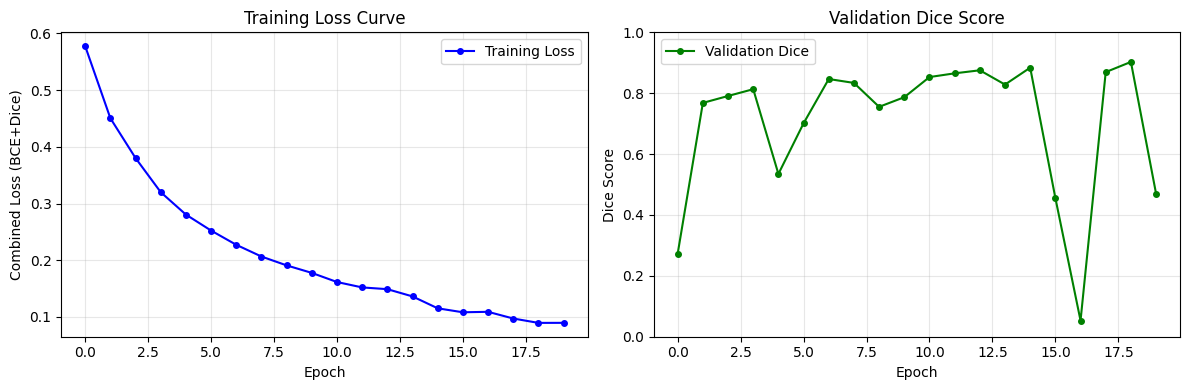

Final Validation Dice: 0.4699


In [ ]:
if TORCH_AVAILABLE:
    class SyntheticSegDataset(Dataset):
        def __init__(self, n_samples=200, size=128):
            self.n_samples = n_samples
            self.size = size

        def __len__(self): return self.n_samples

        def __getitem__(self, idx):
            np.random.seed(idx)
            size = self.size
            img = np.zeros((size, size), dtype=np.float32) + 0.05 + np.random.normal(0, 0.02, (size, size))
            mask = np.zeros((size, size), dtype=np.float32)

            # Body
            rr, cc = disk((size//2, size//2), size//2 - 5)
            img[rr, cc] = 0.55 + np.random.normal(0, 0.03)

            # Organ (liver-like ellipse, random position/size)
            cy = size//2 + np.random.randint(-15, 15)
            cx = size//3 + np.random.randint(-10, 10)
            ry = 25 + np.random.randint(-5, 10)
            rx = 20 + np.random.randint(-5, 10)
            rr, cc = ellipse(cy, cx, ry, rx)
            valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
            img[rr[valid], cc[valid]] = 0.58 + np.random.normal(0, 0.02)
            mask[rr[valid], cc[valid]] = 1.0

            img = np.clip(img + np.random.normal(0, 0.04, img.shape), 0, 1)

            return (torch.tensor(img).unsqueeze(0),  # (1, H, W)
                    torch.tensor(mask).unsqueeze(0))   # (1, H, W)

    # Training
    def dice_loss(pred, target, smooth=1.0):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        return 1 - (2*intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

    def combined_loss(pred, target):
        return 0.5 * nn.BCELoss()(pred, target) + 0.5 * dice_loss(pred, target)

    train_ds = SyntheticSegDataset(n_samples=200, size=128)
    val_ds = SyntheticSegDataset(n_samples=40, size=128)
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=8)

    # Fix: Ensure model parameters are float32 to match input data explicitly at instantiation
    model = MiniUNet(features=[32, 64, 128]).to(torch.float32)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 20
    train_losses, val_dices = [], []

    print("🚀 Training Mini U-Net...")
    print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Val Dice':>9}")
    print("-" * 35)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for imgs, masks in train_loader:
            optimizer.zero_grad()
            # Explicitly cast input images to float32 to match model parameters
            preds = model(imgs.float())
            loss = combined_loss(preds, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        val_dice_total = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                # Explicitly cast input images to float32 for validation as well
                preds = model(imgs.float())
                preds_bin = (preds > 0.5).float()
                intersection = (preds_bin * masks).sum()
                val_dice_total += (2*intersection / (preds_bin.sum() + masks.sum() + 1e-8)).item()

        avg_loss = epoch_loss / len(train_loader)
        avg_dice = val_dice_total / len(val_loader)
        train_losses.append(avg_loss)
        val_dices.append(avg_dice)

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"{epoch+1:>6} | {avg_loss:>11.4f} | {avg_dice:>9.4f}")

    print("\n✅ Training complete!")

    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, 'b-o', markersize=4, label='Training Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Combined Loss (BCE+Dice)')
    ax1.set_title('Training Loss Curve'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(val_dices, 'g-o', markersize=4, label='Validation Dice')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score')
    ax2.set_title('Validation Dice Score'); ax2.legend(); ax2.grid(alpha=0.3)
    ax2.set_ylim([0, 1])
    plt.tight_layout()
    plt.show()
    print(f"Final Validation Dice: {val_dices[-1]:.4f}")

## Part 7: Segmentation Methods Comparison

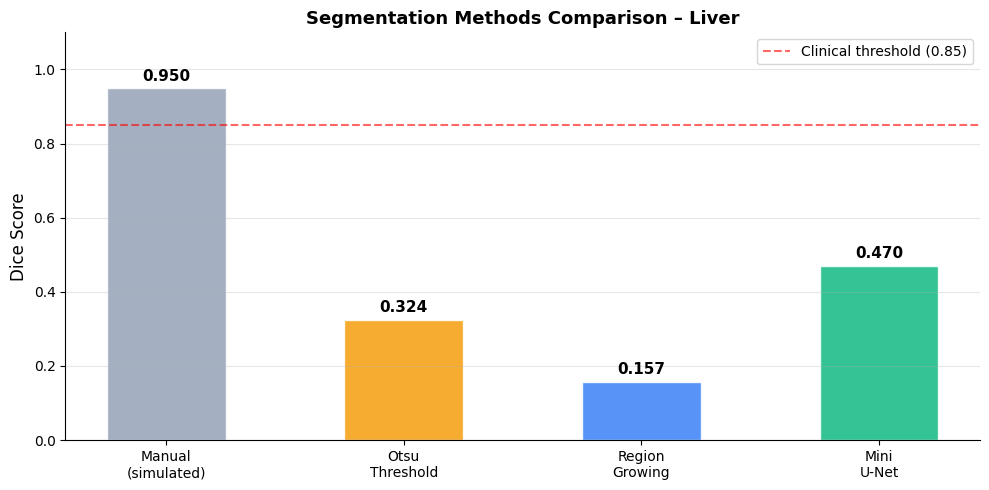

In [ ]:
methods = ['Manual\n(simulated)', 'Otsu\nThreshold', 'Region\nGrowing']
dices = [
    0.95,  # Simulated manual
    dice_coefficient(otsu_seg, liver_gt),
    dice_coefficient(liver_rg, liver_gt)
]

if TORCH_AVAILABLE:
    methods.append('Mini\nU-Net')
    dices.append(val_dices[-1])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#94A3B8', '#F59E0B', '#3B82F6', '#10B981'][:len(methods)]
bars = ax.bar(methods, dices, color=colors, alpha=0.85, width=0.5, edgecolor='white')
ax.set_ylabel('Dice Score', fontsize=12)
ax.set_title('Segmentation Methods Comparison – Liver', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.6, label='Clinical threshold (0.85)')
ax.legend()
for bar, dice in zip(bars, dices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{dice:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Exercises

**Exercise 1:** Modify the region growing tolerance from 0.08 to 0.15. What happens? Explain why.

**Exercise 2:** Change MiniUNet features from [32,64,128] to [16,32,64]. Compare parameter counts and final Dice.

**Exercise 3:** Implement a simple data augmentation (random horizontal flip) in the Dataset class. Does training Dice improve?

**Exercise 4:** Add a tumor segmentation head to MiniUNet (out_ch=2 for liver+tumor). What changes are needed?